# Two steps Neural Networks

In [12]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
#from ann_functions3D_noise_fourier import getModel, kCrossVal, transfBestparam, import_data, normalization
#from Multifidelity_support import getModel, kCrossVal, transfBestparam, import_data, normalization, add_noise, MultiFidelity

from time import perf_counter
import pandas
import pickle
import os
from itertools import product
import keras
import tensorflow as tf
import sys
from module_utils import * 
sys.path.append('../utils')
from Structure import *

from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)

True

In [13]:
# reproducibility
seed=42
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

## Data preparation

In [14]:
Discretizations= np.loadtxt(
    "../DATA_reaction/Discretizations.txt"
).astype(
    int
)[::-1]

diffusion= np.loadtxt(
    "../DATA_reaction/diffusion.txt"
).astype(
    int
)

# I create a list of the models
model_list=[0]*len(Discretizations)

In [15]:
########################     PREPARATION      ##########################
# introduction of the data
file_path_HF = "../DATA_reaction/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test, x_HF_test) = import_data(file_path_HF)
# I consider the reaction term and the position as a variables
U_HF_test = U_HF_test[:, -1, :,44]

# normalization of the data
reaction_HF_test = normalization(reaction_HF_test)
x_HF_test = normalization(x_HF_test)
U_HF_test = normalization(U_HF_test)
# transformation of the dataseet
reaction_HF_test_original=reaction_HF_test
x_HF_test_original=x_HF_test
U_HF_test_original=U_HF_test

In [16]:
# data augmentation introducing a noise
noise_stddev2 = [0.01,0.005,0.02,0.005]      
noise_stddev1 = [0.005,0.003,0.01,0.003]  

(U_HF_test,reaction_HF_test)=add_noise(noise_stddev1,noise_stddev2,reaction_HF_test,U_HF_test)

In [17]:
noise_stddev2 = [0.0001,  0.00005, 0.0002, 0.00005]# value?
noise_stddev1=[0.0025, 0.0015, 0.005, 0.0015  ]

(U_HF_test,x_HF_test)=add_noise(noise_stddev1,noise_stddev2,x_HF_test,U_HF_test.T)
U_HF_test=U_HF_test.T


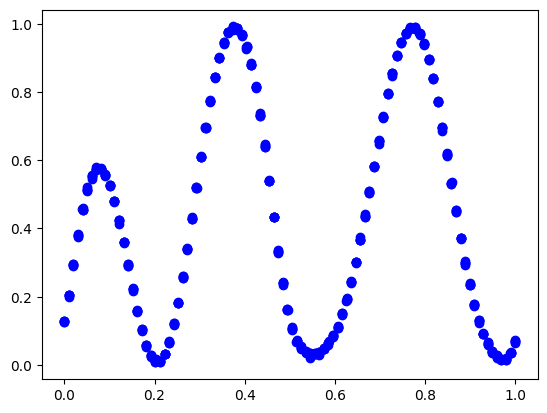

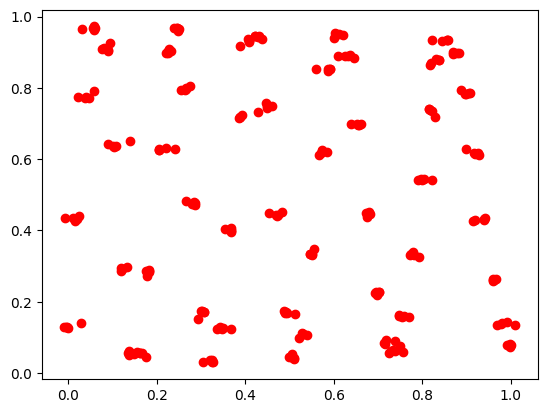

In [18]:
# plot of the dataset

plt.plot(x_HF_test, U_HF_test[0,:], "bo", linewidth=1, label="HF model")
plt.show()

plt.plot(reaction_HF_test, U_HF_test[:,0], "ro", linewidth=1, label="HF model")
plt.show()


In [19]:
# Number of data of High and Low Fidelity components of the dataset
Nepo = [2000,2000]  # number of epochs for second NN: NN_HF
batch_size=[150,80]

Nlf=150
n_HF=80

In [20]:
reaction_HF_test_original=np.array(list(product(reaction_HF_test_original.flatten(), x_HF_test_original.flatten())))


permutation1 = np.random.permutation(len(reaction_HF_test))
permutation2 = np.random.permutation(len(x_HF_test))

reaction_HF = reaction_HF_test[permutation1][0:n_HF]
x_HF = x_HF_test[permutation2][0:n_HF]

grid1, grid2 = np.meshgrid(reaction_HF, x_HF)
reaction_HF = np.column_stack((grid1.ravel(), grid2.ravel()))
reaction_HF_test = np.array(list(product(reaction_HF_test.flatten(), x_HF_test.flatten())))

reaction_HF_test_original=np.c_[reaction_HF_test_original,np.abs(np.sin(5*np.pi*reaction_HF_test_original[:, 0])) ,np.abs(np.sin(3.5*np.pi*reaction_HF_test_original[:, 1])),np.ones(reaction_HF_test_original.shape[0])]
reaction_HF=np.c_[reaction_HF, np.abs(np.sin(5*np.pi*reaction_HF[:, 0])),np.abs(np.sin(3.5*np.pi*reaction_HF[:, 1])),np.ones(reaction_HF.shape[0])]
reaction_HF_test=np.c_[reaction_HF_test,np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0])) ,np.abs(np.sin(3.5*np.pi*reaction_HF_test[:, 1])),np.ones(reaction_HF_test.shape[0])]


p1, p2 = np.meshgrid(permutation1[0:n_HF], permutation2[0:n_HF])
permutation = np.column_stack((p1.ravel(), p2.ravel()))
U_HF = U_HF_test[permutation[:,0],permutation[:,1]] 
row, col = U_HF_test.shape
index_row, index_col = np.meshgrid(np.arange(row), np.arange(col), indexing='ij')
comb = np.ravel_multi_index((index_row.flatten(), index_col.flatten()), dims=(row, col))
U_HF_test = U_HF_test.flatten()[comb]

row, col = U_HF_test_original.shape
index_row, index_col = np.meshgrid(np.arange(row), np.arange(col), indexing='ij')
comb = np.ravel_multi_index((index_row.flatten(), index_col.flatten()), dims=(row, col))
U_HF_test_original = U_HF_test_original.flatten()[comb]


In [21]:
U_LF_list = []
U_HF_list = []

r2_HF_df = pandas.DataFrame(columns=['Discretization','diffusion','R2'])  # dataframe which stores HF R^2
r2_LF_df = pandas.DataFrame(columns=['Discretization','diffusion','R2'])  # dataframe which stores LF R^2
mse_HF_df = pandas.DataFrame(columns=['Discretization','diffusion','MSE'])  # dataframe which stores HF MSE
mse_LF_df = pandas.DataFrame(columns=['Discretization','diffusion','MSE'])  # dataframe which stores LF MSE

## Neural Network
Cycle on the Discretization and the value of the diffusion 

Folder '2_step_models_multiparam' already exists.
********************  # Nb. nodes = 46  ********************
********************  # Diff: = 0  ********************
The function training took 542.0367918014526 seconds.


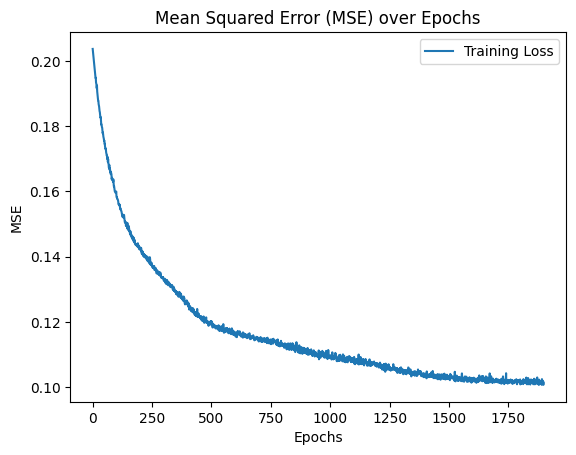

The function training took 184.21107697486877 seconds.


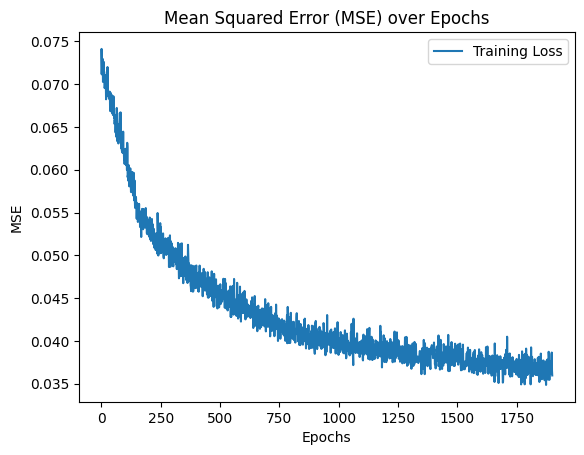

low fidelity NN
Test MSE: 0.08168146768283849
R^2: 0.345072955263237
Test MSE: 0.05375567188895143
R^2: 0.5186035831308815


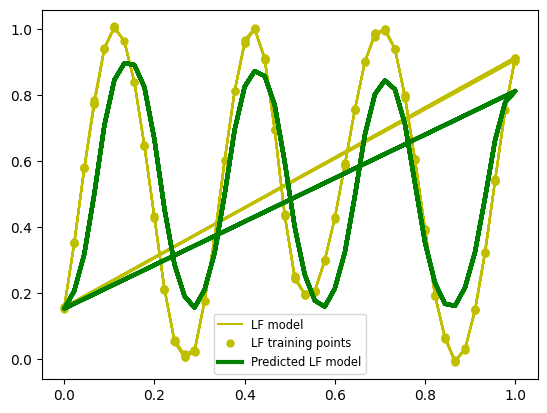

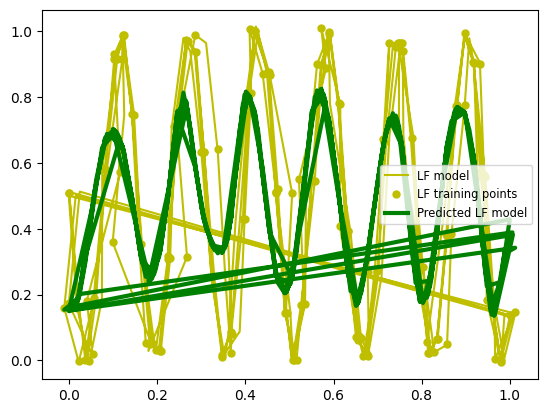

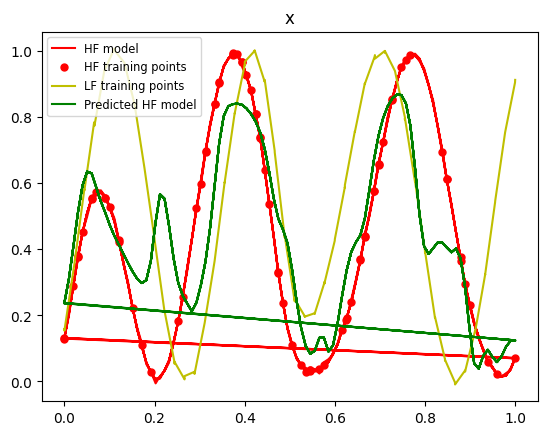

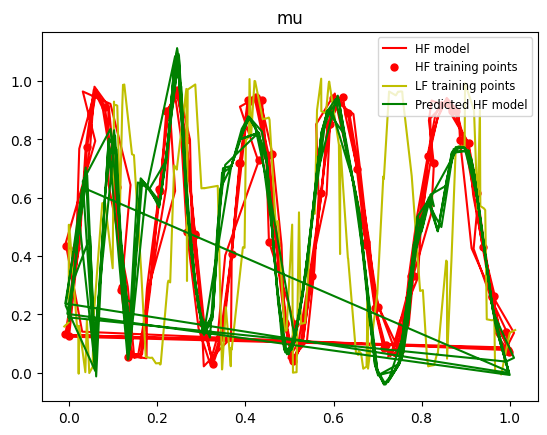

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_28220\4172885873.py:283: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  r2_LF_df = pandas.concat([r2_LF_df, pandas.DataFrame([new_data])], ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_28220\4172885873.py:287: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  r2_HF_df = pandas.concat([r2_HF_df, pandas.DataFrame([new_data])], ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_28220\4172885873.py:291: FutureWarning: The beha

Saving ...
********************  # Nb. nodes = 46  ********************
********************  # Diff: = 5  ********************
The function training took 513.9247257709503 seconds.


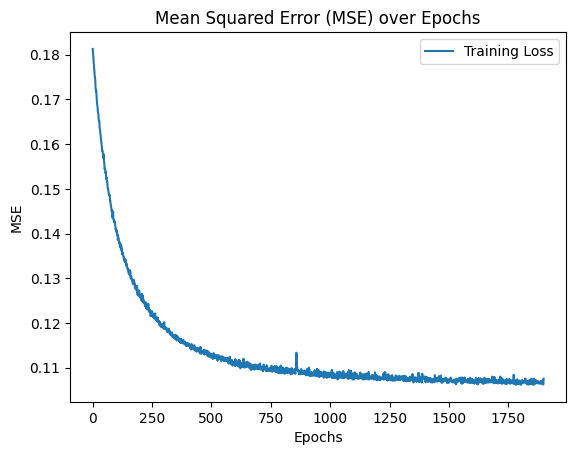

The function training took 184.0926423072815 seconds.


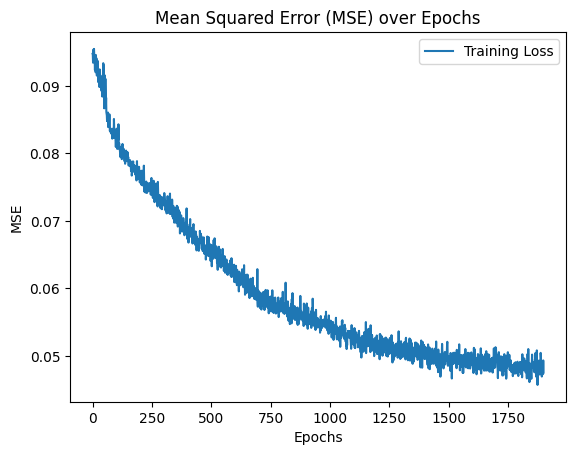

low fidelity NN
Test MSE: 0.10138154739666146
R^2: 0.08257814641936545
Test MSE: 0.07783566830835932
R^2: 0.3029607758291517


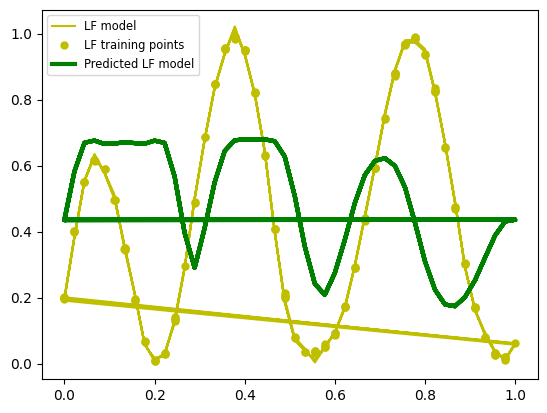

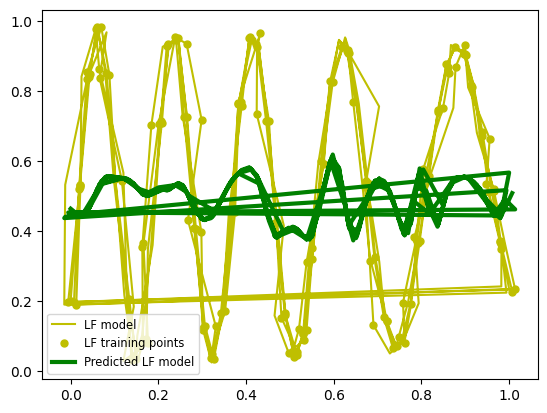

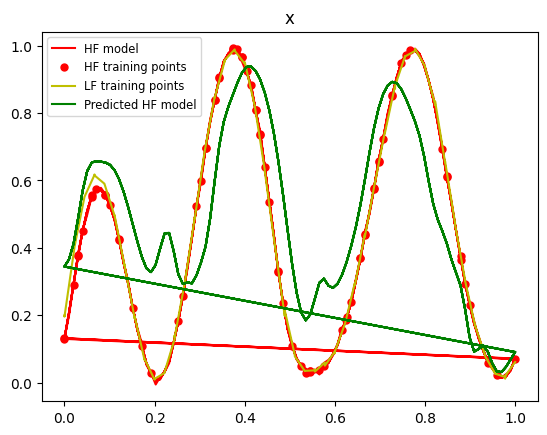

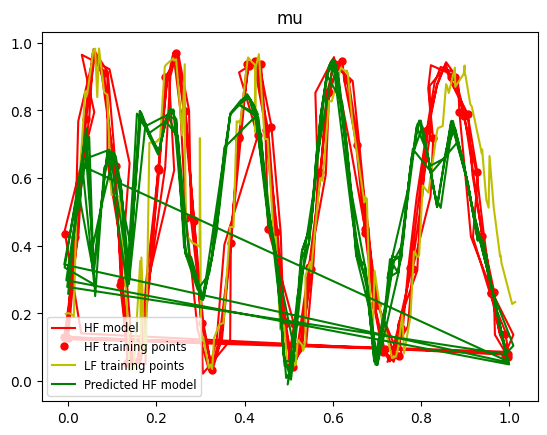

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 75  ********************
The function training took 513.6038568019867 seconds.


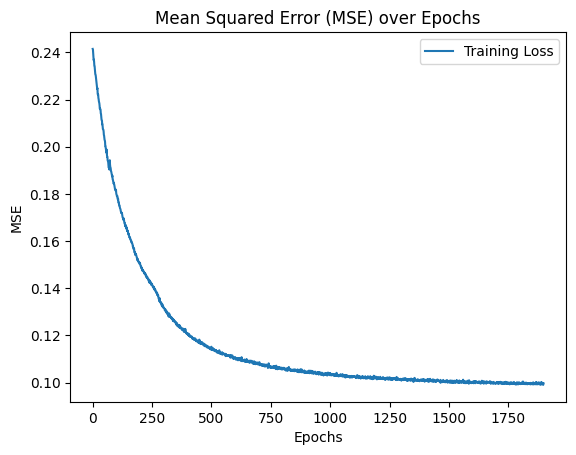

The function training took 184.21791291236877 seconds.


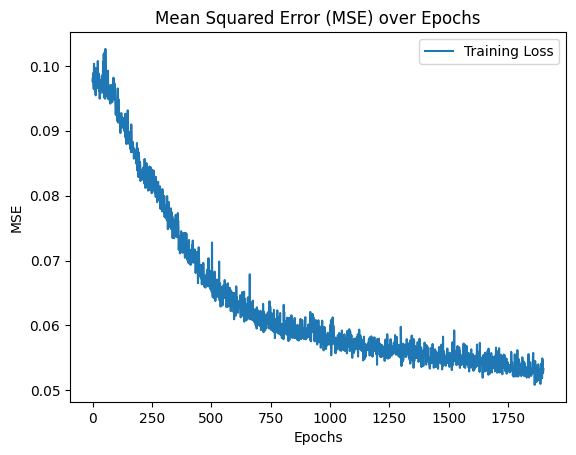

low fidelity NN
Test MSE: 0.09131477230379519
R^2: 0.17012586442786093
Test MSE: 0.0801105535566554
R^2: 0.2825885700909284


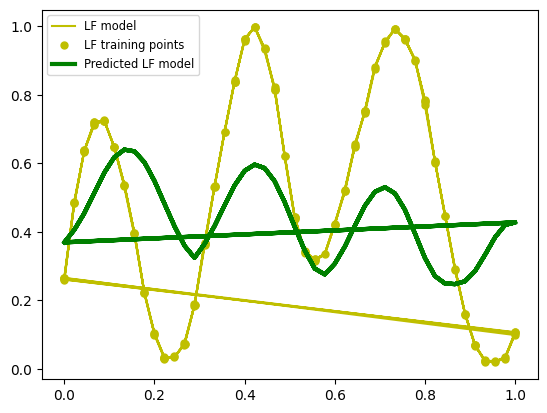

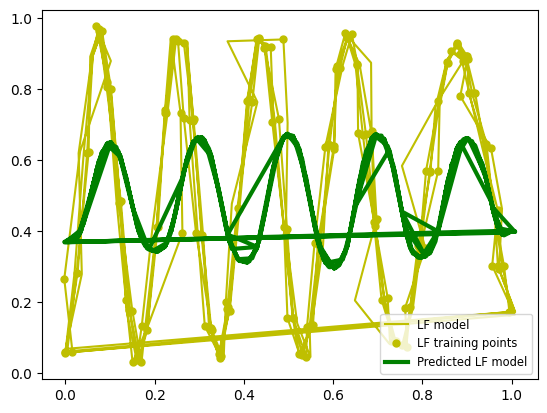

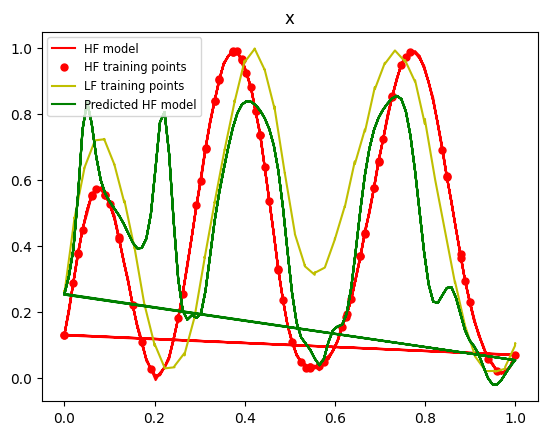

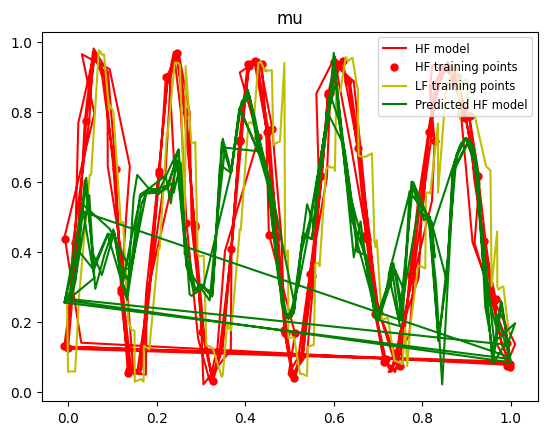

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 1  ********************
The function training took 792.3075878620148 seconds.


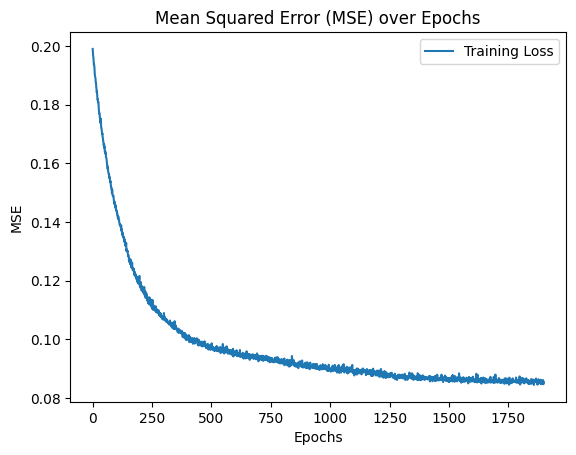

The function training took 180.70744609832764 seconds.


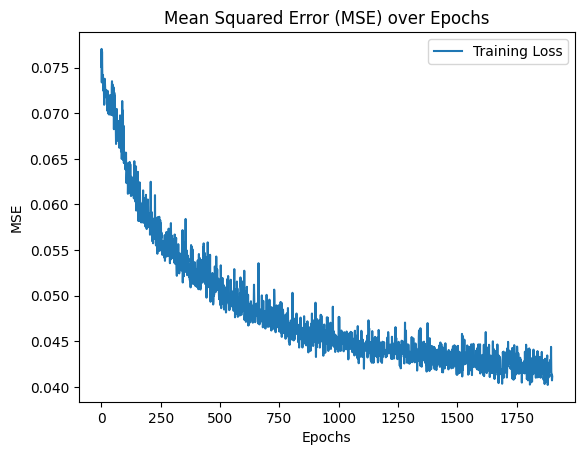

low fidelity NN
Test MSE: 0.07099964242086126
R^2: 0.3504806523400579
Test MSE: 0.06689141611849089
R^2: 0.4009694808528447


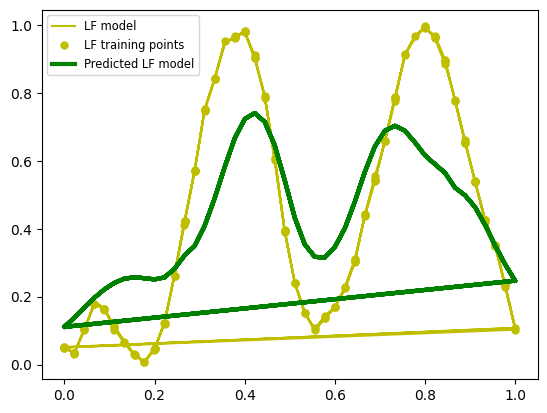

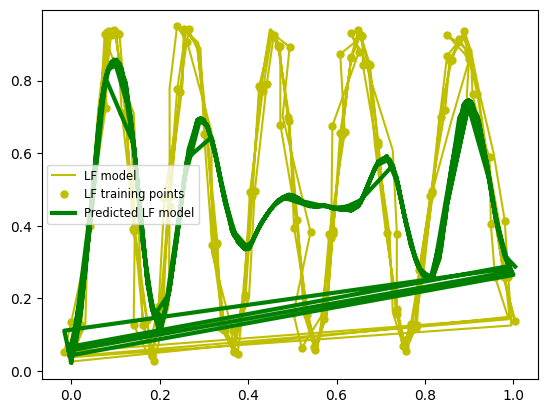

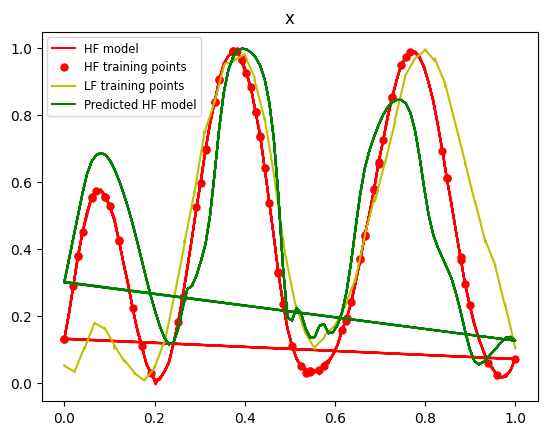

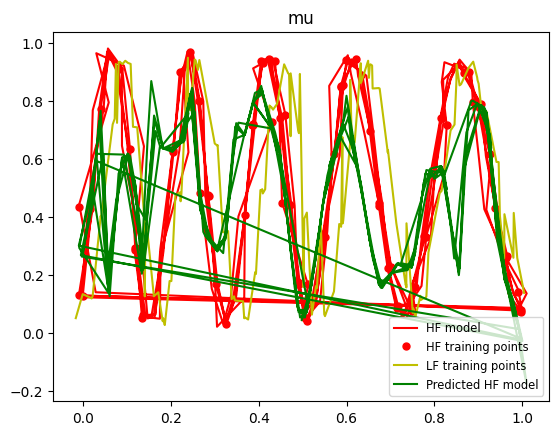

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 0  ********************
The function training took 459.6764886379242 seconds.


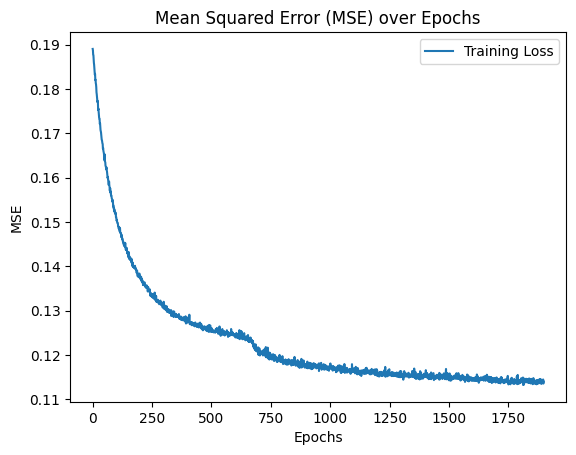

The function training took 181.61316394805908 seconds.


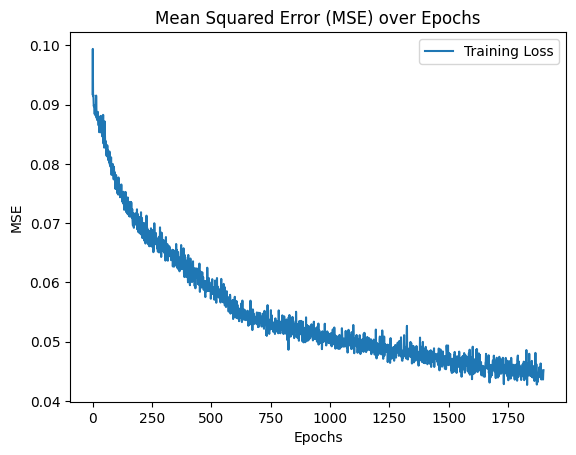

low fidelity NN
Test MSE: 0.10319028897269204
R^2: 0.17262160389890013
Test MSE: 0.07840296926349116
R^2: 0.2978804440708387


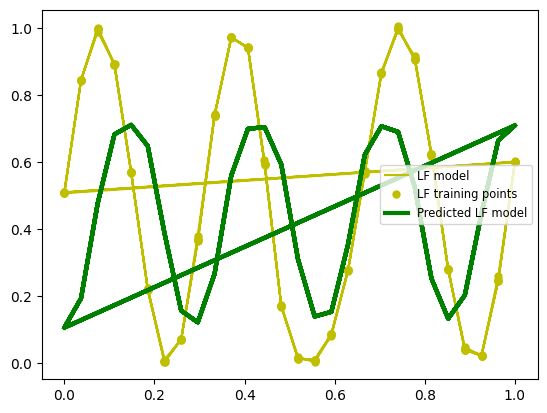

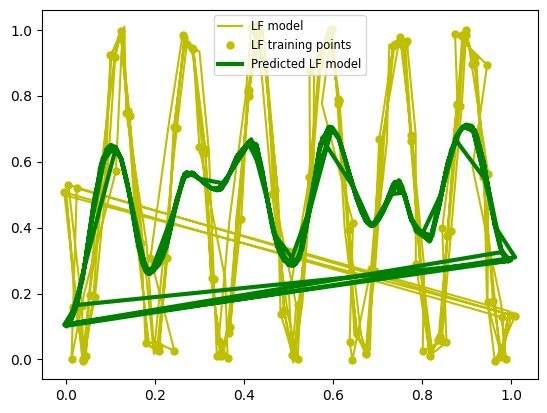

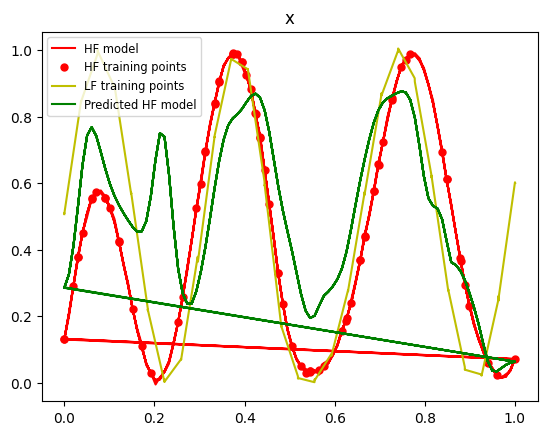

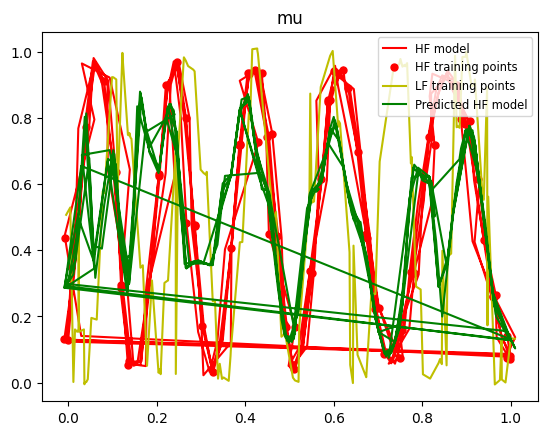

Saving ...
********************  # Nb. nodes = 28  ********************
********************  # Diff: = 5  ********************


c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Multiparameter\../utils\Structure.py:863: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  save_model(self.model_list[index].model,folder)


The function training took 469.76864767074585 seconds.


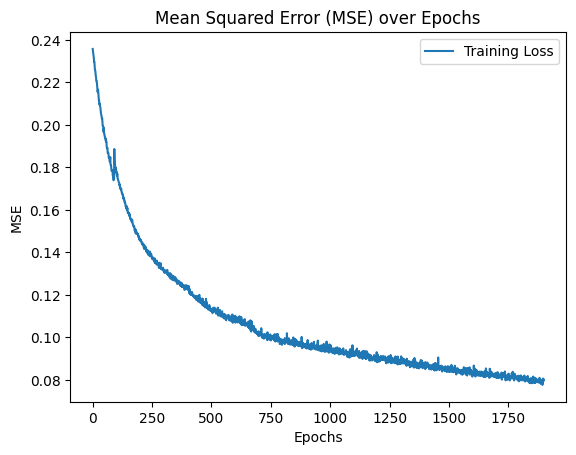

The function training took 187.1893002986908 seconds.


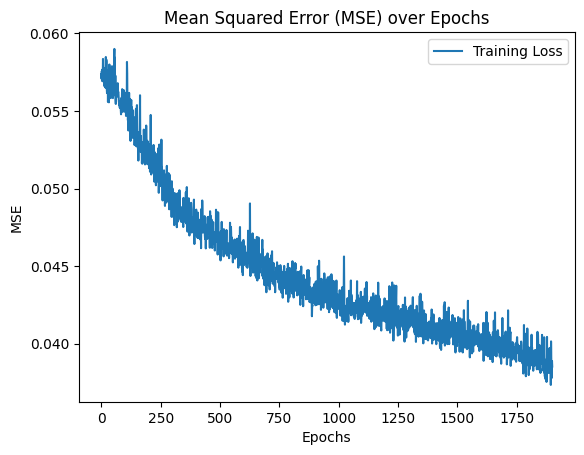

low fidelity NN
Test MSE: 0.054688039847441194
R^2: 0.5115704498983309
Test MSE: 0.06202620846163836
R^2: 0.44453871645223064


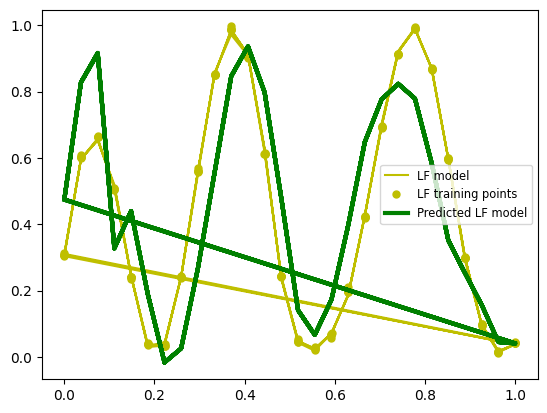

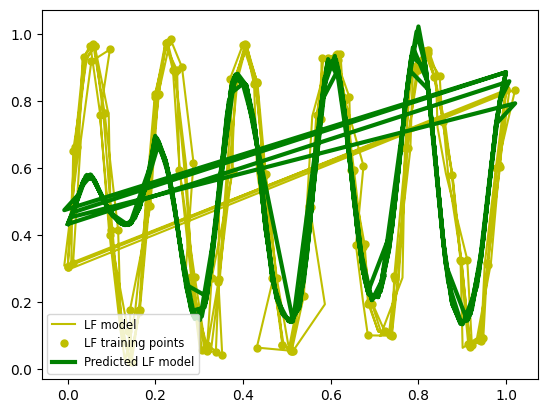

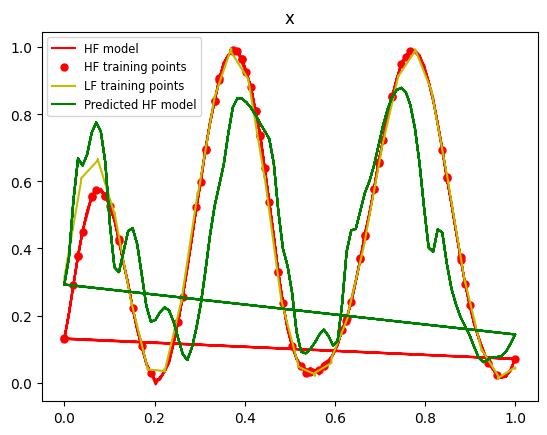

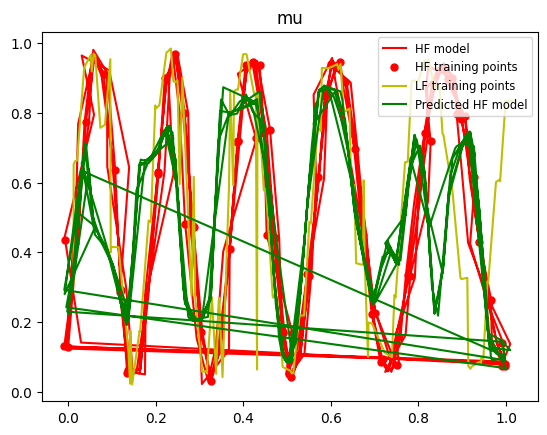

Saving ...
********************  # Nb. nodes = 28  ********************
********************  # Diff: = 75  ********************


c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Multiparameter\../utils\Structure.py:863: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  save_model(self.model_list[index].model,folder)


The function training took 475.41345405578613 seconds.


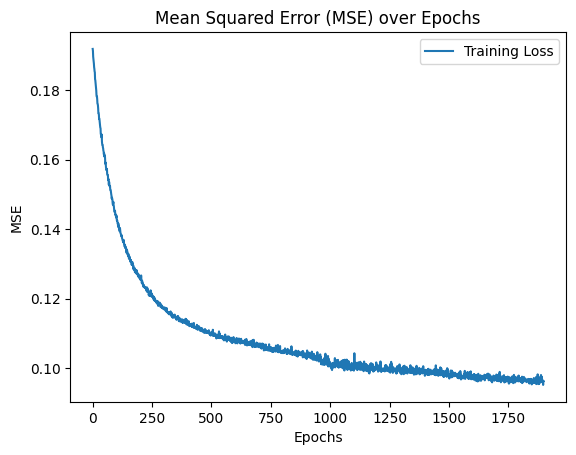

The function training took 184.2656192779541 seconds.


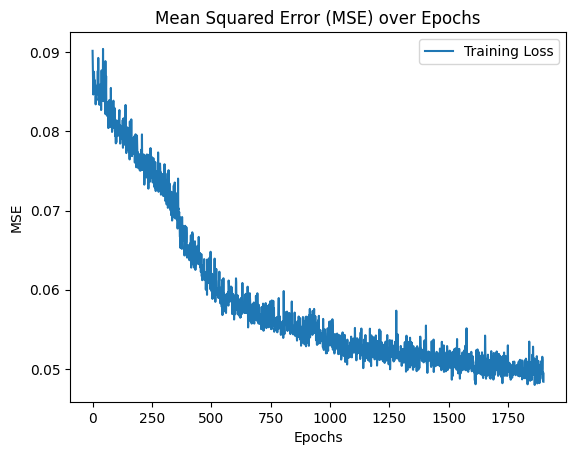

low fidelity NN
Test MSE: 0.07880819637854744
R^2: 0.2746755978014557
Test MSE: 0.08975900514393317
R^2: 0.19618410598068958


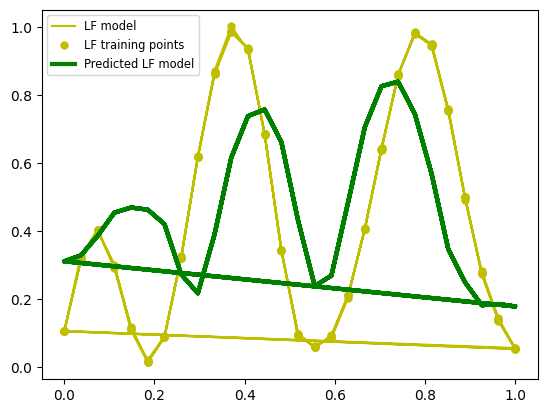

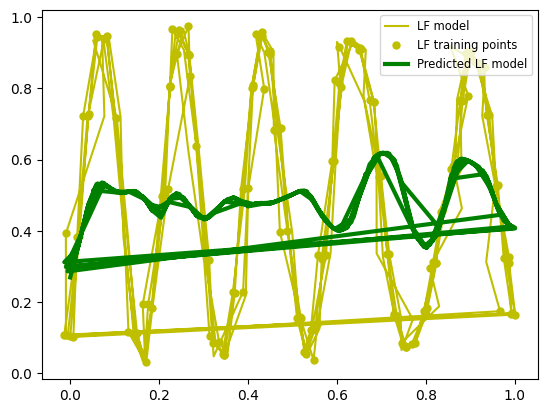

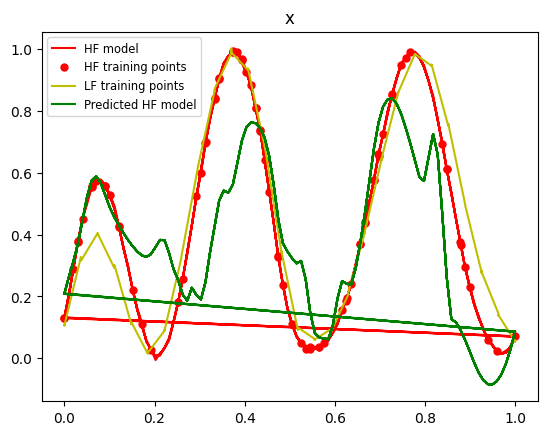

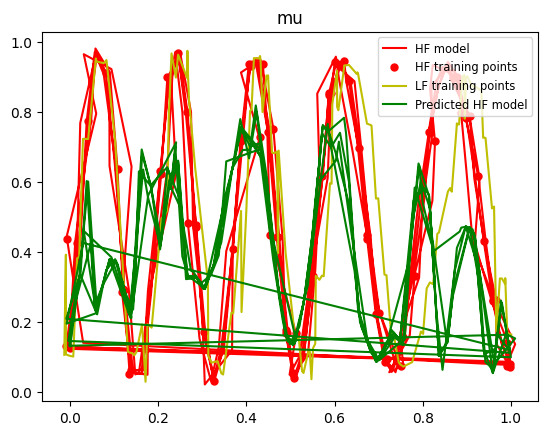

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 1  ********************
The function training took 472.1932556629181 seconds.


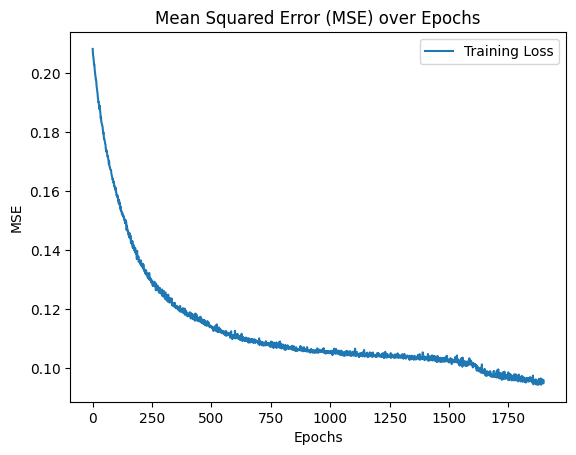

The function training took 331.8140814304352 seconds.


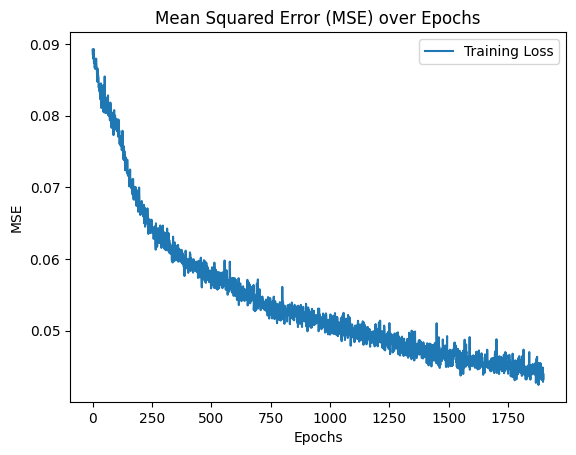

low fidelity NN
Test MSE: 0.07573490814991331
R^2: 0.2958865582506991
Test MSE: 0.07413498992655641
R^2: 0.3361013403572102


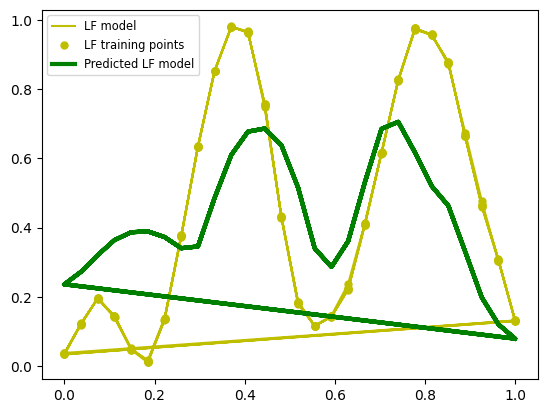

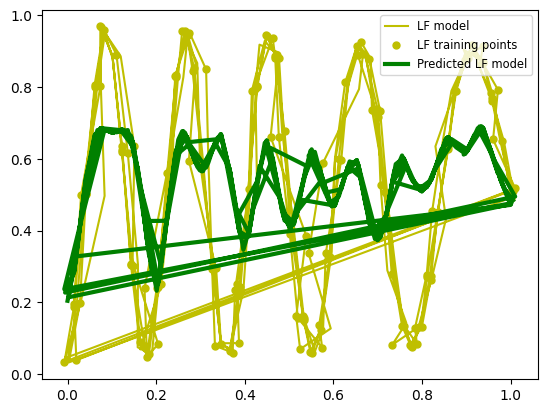

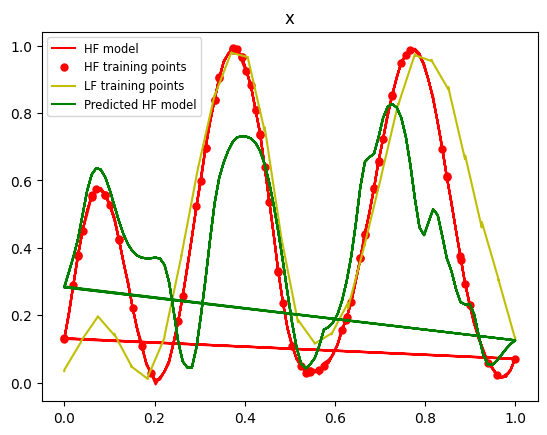

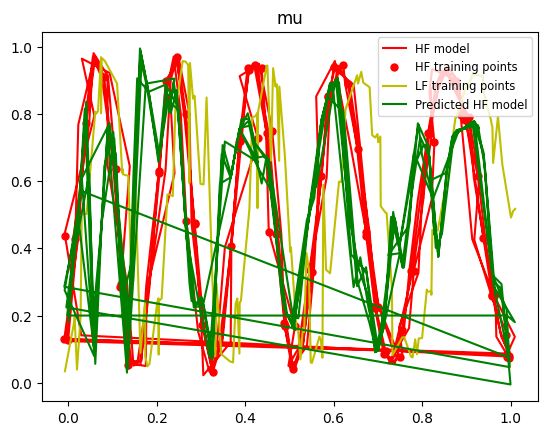

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 0  ********************
The function training took 317.3003673553467 seconds.


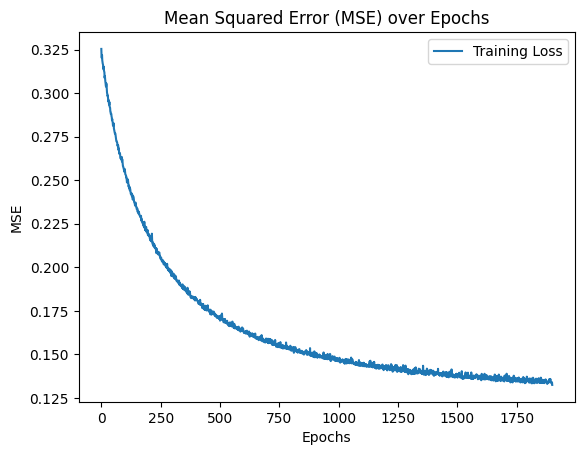

The function training took 359.0330138206482 seconds.


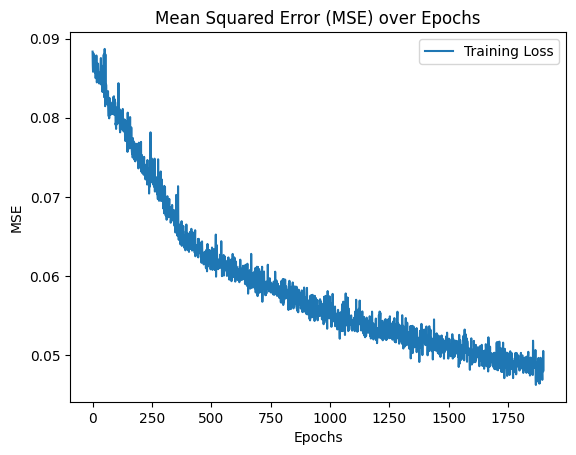

low fidelity NN
Test MSE: 0.10409503911427721
R^2: 0.1662463451489795
Test MSE: 0.08710085942804029
R^2: 0.21998851169605826


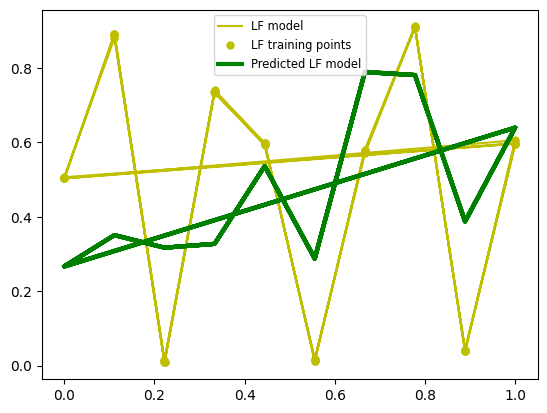

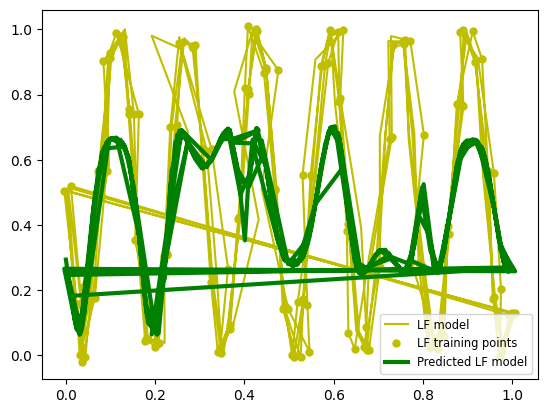

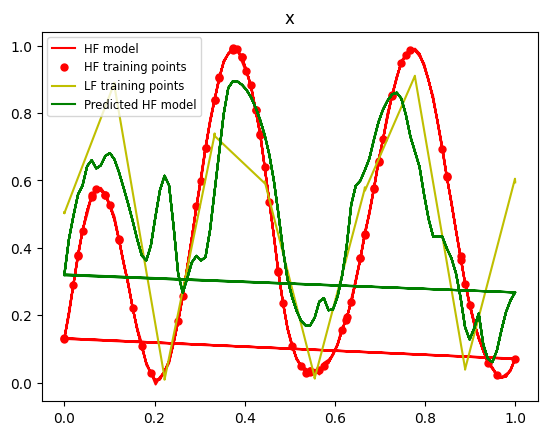

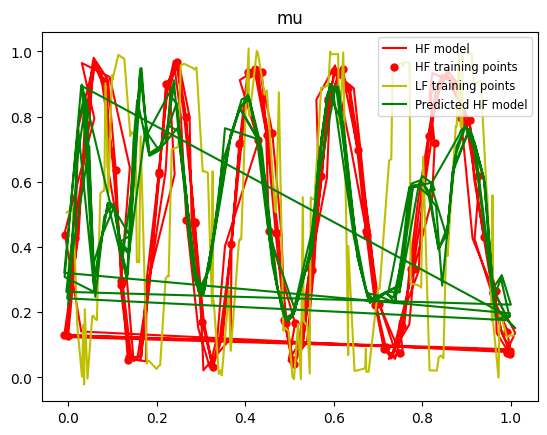

Saving ...
********************  # Nb. nodes = 10  ********************
********************  # Diff: = 5  ********************


c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Multiparameter\../utils\Structure.py:863: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  save_model(self.model_list[index].model,folder)


The function training took 238.08182001113892 seconds.


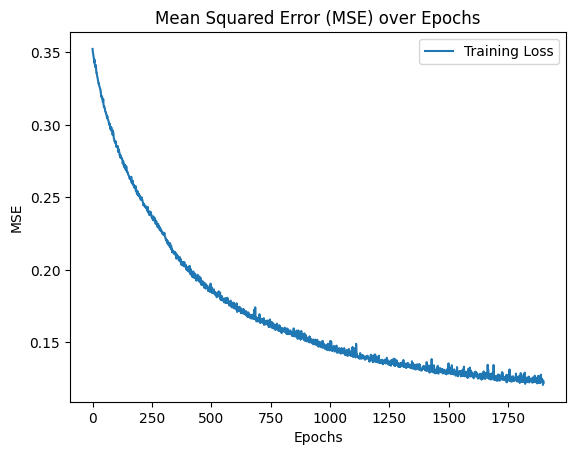

The function training took 187.0636465549469 seconds.


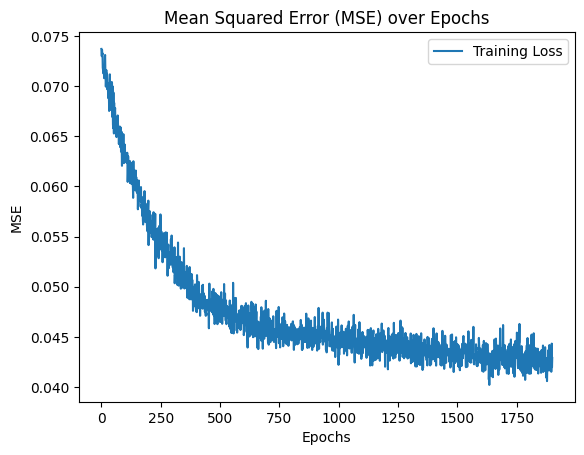

low fidelity NN
Test MSE: 0.07977174792590418
R^2: 0.3552043259121376
Test MSE: 0.07009957919668283
R^2: 0.3722395225748826


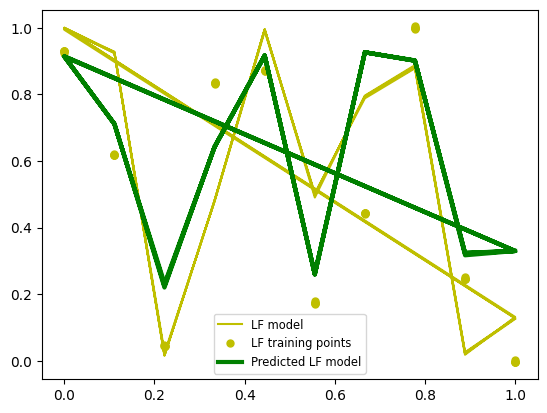

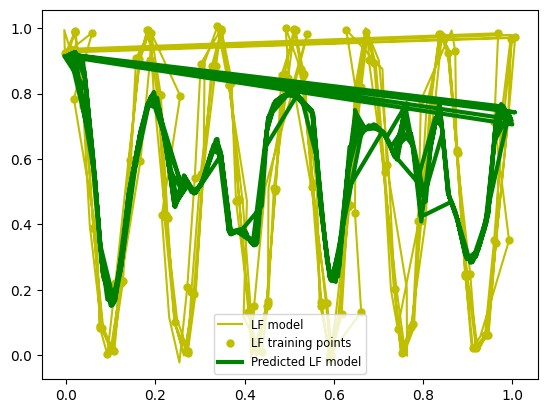

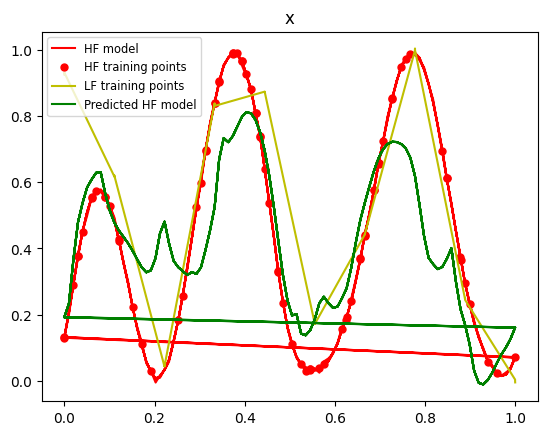

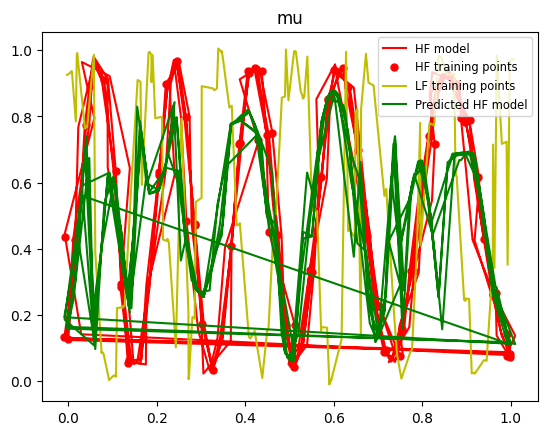

Saving ...
********************  # Nb. nodes = 10  ********************
********************  # Diff: = 75  ********************


c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Multiparameter\../utils\Structure.py:863: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  save_model(self.model_list[index].model,folder)


The function training took 173.06769967079163 seconds.


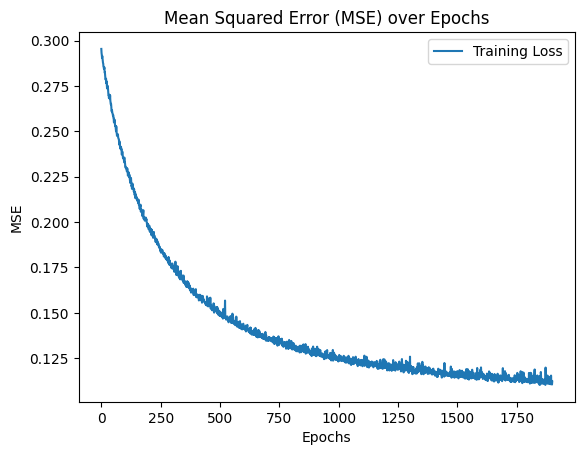

The function training took 185.38626194000244 seconds.


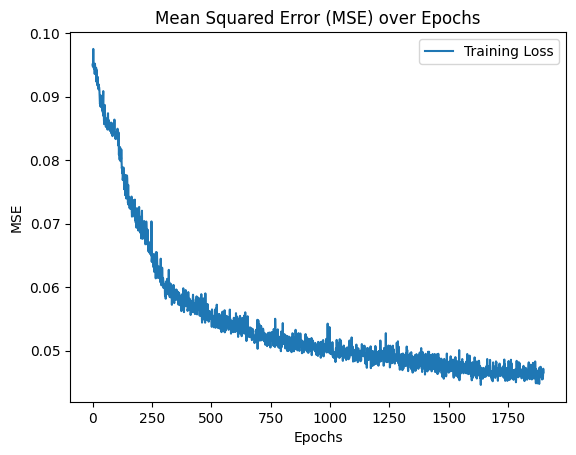

low fidelity NN
Test MSE: 0.0902752032968277
R^2: 0.2651153199201386
Test MSE: 0.0805203461931898
R^2: 0.278918767445832


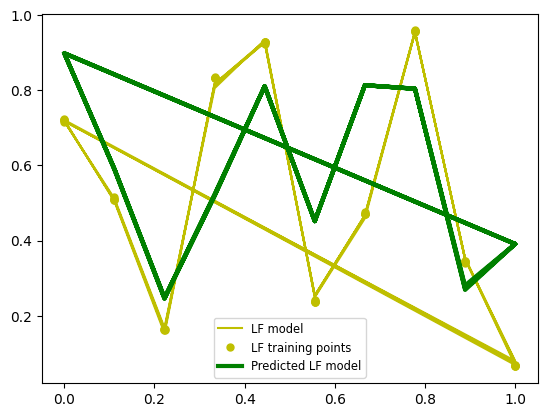

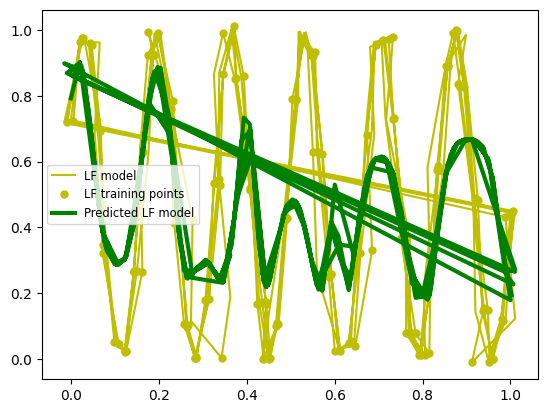

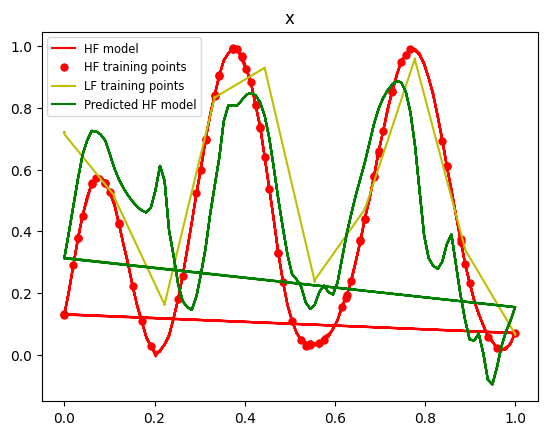

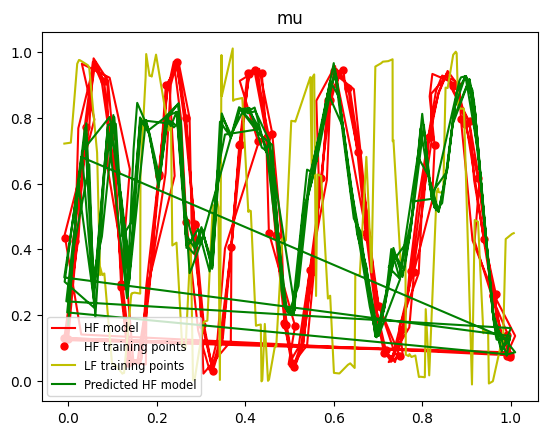

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 1  ********************
The function training took 197.38929271697998 seconds.


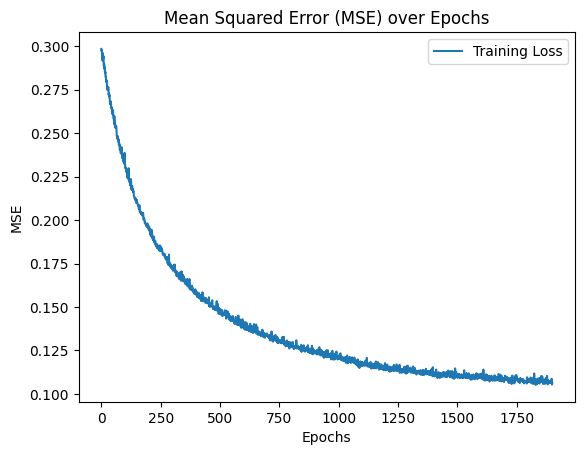

The function training took 188.50088000297546 seconds.


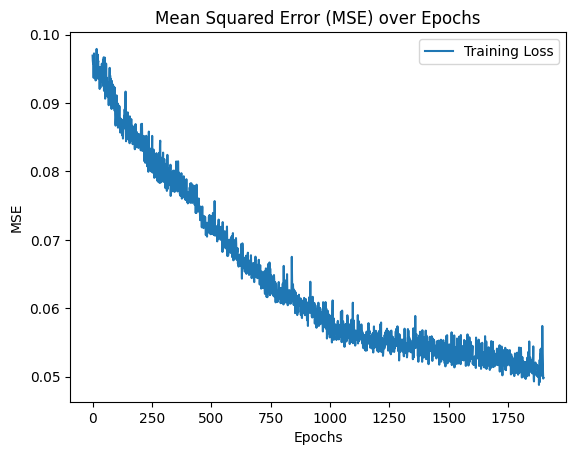

low fidelity NN
Test MSE: 0.07330981491400707
R^2: 0.38530646784162526
Test MSE: 0.09456643159448298
R^2: 0.15313231653533876


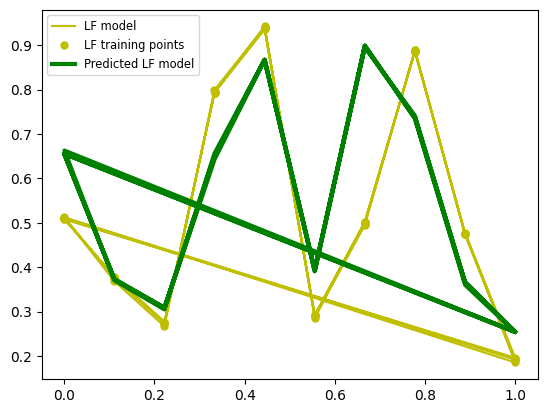

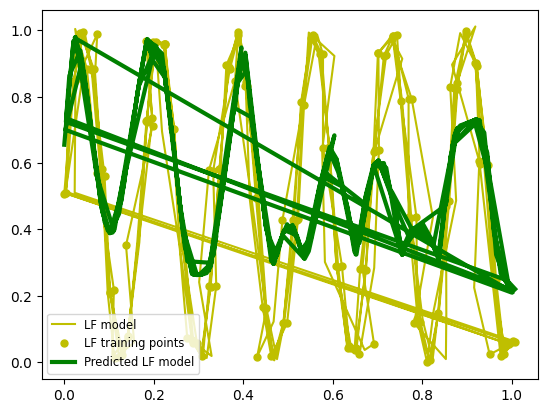

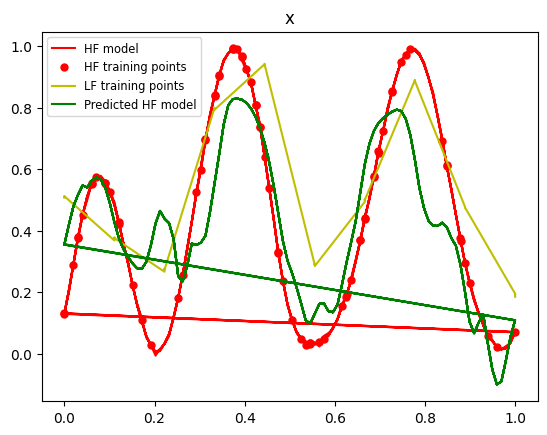

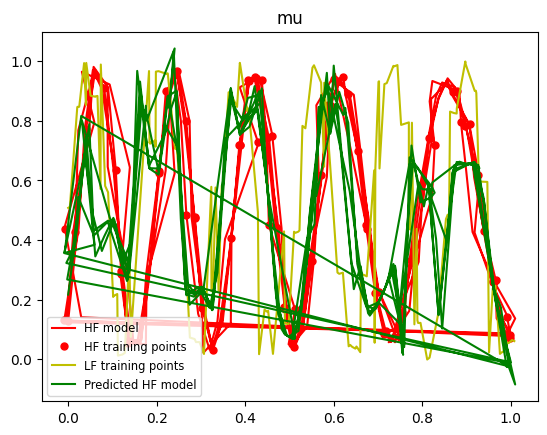

   Discretization diffusion       R2
0              46         0  0.51860
1              46         5  0.30296
2              46        75  0.28259
3              46         1  0.40097
4              28         0  0.29788
5              28         5  0.44454
6              28        75  0.19618
7              28         1  0.33610
8              10         0  0.21999
9              10         5  0.37224
10             10        75  0.27892
11             10         1  0.15313
   Discretization diffusion      MSE       R2
0              46         0  0.05376  0.51860
1              46         5  0.07784  0.30296
2              46        75  0.08011  0.28259
3              46         1  0.06689  0.40097
4              28         0  0.07840  0.29788
5              28         5  0.06203  0.44454
6              28        75  0.08976  0.19618
7              28         1  0.07413  0.33610
8              10         0  0.08710  0.21999
9              10         5  0.07010  0.37224
10           

In [22]:

# Name of the folder
folder_name = "2_step_models_multiparam"
folder_path = os.path.join(os.getcwd(), folder_name)

# create the folder
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Folder '{folder_name}' created.")
else:
    print(f"Folder '{folder_name}' already exists.")
               

for m in range(len(Discretizations)):
    test_mse_HF_list = []
    test_mse_LF_list = []

    r2_HF_list = []
    r2_LF_list = []
    for d in range(len(diffusion)):
        
        print(
        f"********************  # Nb. nodes = {Discretizations[m]}  ********************"
        )
        
        print(
        f"********************  # Diff: = {diffusion[d]}  ********************"
        )
        file_name= "../DATA_reaction/reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat"
        (reaction_LF_test, U_LF_test, x_LF_test) = import_data(file_name)
       
        U_LF_test = U_LF_test[
        :,
        - 1,
        :,
        int(4*(Discretizations[m]-1)/9)
        ]
         
        reaction_LF_test = normalization(reaction_LF_test)
        x_LF_test = normalization(x_LF_test)
        U_LF_test = normalization(U_LF_test)

        reaction_LF_test_original=reaction_LF_test
        x_LF_test_original=x_LF_test
        U_LF_test_original=U_LF_test
        
        noise_std2=[ 0.01 ,0.005 ,0.02,0.005]
        noise_std1=[0.005,0.003,0.01,0.003]
        
        (U_LF_test,reaction_LF_test)=add_noise(noise_std1,noise_std2,reaction_LF_test,U_LF_test)

        noise_std2=[ 0.0001 ,0.00005 ,0.0002,0.00005]
        noise_std1=[0.0025,0.0015,0.005,0.0015]

        (U_LF_test,x_LF_test)=add_noise(noise_std1,noise_std2,x_LF_test,U_LF_test.T)
        U_LF_test=U_LF_test.T

        reaction_LF_test_original=np.array(list(product(reaction_LF_test_original.flatten(), x_LF_test_original.flatten())))
        reaction_LF_test_original=np.c_[reaction_LF_test_original,np.abs(np.sin(5*np.pi*reaction_LF_test_original[:, 0])) ,np.abs(np.sin(3.5*np.pi*reaction_LF_test_original[:, 1])),np.ones(reaction_LF_test_original.shape[0])]

        row, col = U_LF_test_original.shape
        index_row, index_col = np.meshgrid(np.arange(row), np.arange(col), indexing='ij')
        comb = np.ravel_multi_index((index_row.flatten(), index_col.flatten()), dims=(row, col))
        U_LF_test_original = U_LF_test_original.flatten()[comb]

        L=np.minimum(Nlf,x_LF_test.shape[0])
        permutation1 = np.random.permutation(len(reaction_LF_test))
        permutation2 = np.random.permutation(len(x_LF_test))
        reaction_LF = reaction_LF_test[permutation1][0:Nlf]    # problema di consistenza qui: non stai confrontando stesso numero di dati, ma è cosairreparabile se non creando nuovo dataset
        x_LF = x_LF_test[permutation2][0:L]
        
        grid1, grid2 = np.meshgrid(reaction_LF, x_LF)
        reaction_LF = np.column_stack((grid1.ravel(), grid2.ravel()))
        reaction_LF_test = np.array(list(product(reaction_LF_test.flatten(), x_LF_test.flatten())))
       
        
        reaction_LF=np.c_[reaction_LF, np.abs(np.sin(5*np.pi*reaction_LF[:, 0])),np.abs(np.sin(3.5*np.pi*reaction_LF[:, 1])),np.ones(reaction_LF.shape[0])]
        reaction_LF_test=np.c_[reaction_LF_test,np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0])) ,np.abs(np.sin(3.5*np.pi*reaction_LF_test[:, 1])),np.ones(reaction_LF_test.shape[0])]

      
        p1, p2 = np.meshgrid(permutation1[0:Nlf], permutation2[0:L])
        permutation = np.column_stack((p1.ravel(), p2.ravel()))
        U_train_LF = U_LF_test[permutation[:,0],permutation[:,1]]
        
        row, col = U_LF_test.shape
        index_row, index_col = np.meshgrid(np.arange(row), np.arange(col), indexing='ij')
        comb = np.ravel_multi_index((index_row.flatten(), index_col.flatten()), dims=(row, col))
        U_LF_test = U_LF_test.flatten()[comb]

        
        ##########################       Neural Network    ##########################
        K.clear_session()
        bestLF_params = {
            "lr": 0.0255,
            "kernel_init": "glorot_uniform",
            "opt": "Adam",
        } 

        best_params = {
            "kernel_init": "uniform",
            "l2weight": 0.0002588943618918075,
            "lr": 0.008365144388542751,
            "nodes": 64.0,
            "opt": "Adam",
        }

        # Multifidelity network 
        names=["LF","HF"]
        params=[bestLF_params, best_params]
        data_train=[reaction_LF, reaction_HF]
        output_train=[U_train_LF,U_HF]
        
        model= NetworkFactory.build_network("2step",names,params=params,data_train=data_train,output_train=output_train,N=Nepo,n=batch_size,do_HPO=False,verbose=False)

        # low fidelity part of the network 
        ULF = model.model_list[0].prediction(reaction_LF_test_original)
        print("low fidelity NN")

        (test_mse_LF,r2_LF) = model.model_list[0].performance(reaction_LF_test_original,U_LF_test_original)
        test_mse_LF_list.append(test_mse_LF)
        r2_LF_list.append(r2_LF)

        # creation of the input of the second part of the 2 steps NN to study the high fidelity model
        reaction_test_help =  model.model_list[0].prediction(reaction_HF_test)[:, 0]
        reaction_test_in = np.concatenate(
        (reaction_HF_test, reaction_test_help.reshape(-1,1)),axis=1
        )   # <- TEST INPUT for the second NN: NN_HF

        reaction_test_help_original = model.model_list[0].prediction(reaction_HF_test_original)[:, 0]
        reaction_test_in_original = np.concatenate(
        (reaction_HF_test_original, reaction_test_help_original.reshape(-1,1)),axis=1
        )   # <- TEST INPUT for the second NN: NN_HF



        reaction_train_help = model.model_list[0].prediction(reaction_HF)[
            :, 0
        ]  # f_LF(mu_hf_train)
        reaction_final = np.concatenate(
        (reaction_HF, reaction_train_help.reshape(-1,1)),axis=1
        )  # <- TRAINING INPUT for the second NN: NN_HF

        UHF =  model.model_list[1].prediction(reaction_test_in_original)
        U_HF_list.append(UHF)

        (test_mse_HF,r2_HF) = model.model_list[1].performance(reaction_test_in_original,U_HF_test_original)
        test_mse_HF_list.append(test_mse_HF)
        r2_HF_list.append(r2_HF)
        
#####
        index_order=np.argsort(reaction_LF_test[:,0])
        index_order_LF=np.argsort(reaction_LF[:,0])

        mask1_test=np.where(reaction_LF_test[:,0]==reaction_LF_test[:,0][index_order[2]])
        mask1_LF=np.where(reaction_LF[:,0]==reaction_LF[:,0][index_order_LF[2]])
        order=np.argsort(reaction_LF[mask1_LF,1])

####

        plt.figure()
        plt.plot(
        reaction_LF_test[mask1_test, 1].T, U_LF_test[mask1_test], "y-", linewidth=1.5, label="LF model"
        )
        plt.plot(
        reaction_LF[mask1_LF, 1].T,
        U_train_LF[mask1_LF],
        "yo",
        markersize=5,
        label="LF training points",
        )
        plt.plot(
        reaction_LF_test[mask1_test, 1].T,
        model.model_list[0].prediction(reaction_LF_test[mask1_test,:][0,:,:]),
        "g-",
        linewidth=3,
        label="Predicted LF model",
        )
        plt.legend(prop={"size": 8.3})
        plt.show()
        
#####
        index_order=np.argsort(reaction_LF_test[:,1])
        index_order_LF=np.argsort(reaction_LF[:,1])

        mask2_test=np.where(reaction_LF_test[:,1]==reaction_LF_test[:,1][index_order[2]])
        mask2_LF=np.where(reaction_LF[:,1]==reaction_LF[:,1][index_order_LF[2]])
        order=np.argsort(reaction_LF[mask2_LF,0])


####
        plt.figure()
        plt.plot(
        reaction_LF_test[mask2_test, 0].T, U_LF_test[mask2_test], "y-", linewidth=1.5, label="LF model"
        )
        plt.plot(
        reaction_LF[mask2_LF, 0].T,
        U_train_LF[mask2_LF],
        "yo",
        markersize=5,
        label="LF training points",
        )
        plt.plot(
        reaction_LF_test[mask2_test, 0].T,
        model.model_list[0].prediction(reaction_LF_test[mask2_test,:][0,:,:]),
        "g-",
        linewidth=3,
        label="Predicted LF model",
        )
        plt.legend(prop={"size": 8.3})
        plt.show()
        
        
           
        index_order=np.argsort(reaction_test_in[:,0])
        index_order_LF=np.argsort(reaction_LF[:,0])
        
        
        plt.figure()
        mask1_test=np.where(reaction_test_in[:,0]==reaction_test_in[:,0][index_order[2]])
        mask1=np.where(reaction_final[:,0]==np.min(reaction_final[:,0]))
        #mask1_LF=np.where(reaction_LF[:,0]==reaction_LF[:,0][index_order_LF[2]])
        order=np.argsort(reaction_LF[mask1_LF,1])

        plt.plot(reaction_test_in[mask1_test,1].T, U_HF_test[mask1_test], "r-", linewidth=1.5, label="HF model")
        plt.plot(reaction_final[mask1,1].T, U_HF[mask1], "ro", markersize=5, label="HF training points")
        plt.plot(reaction_LF[mask1_LF,1].T[order[0,:]], U_train_LF[mask1_LF][order[0,:]], "y-", markersize=5, label="LF training points")
        plt.plot(
        reaction_test_in[mask1_test, 1].T,
        model.model_list[1].prediction(reaction_test_in[mask1_test, :][0,:,:]),
        "g-",
        markersize=5,
        label="Predicted HF model",
        )

        plt.legend(prop={"size": 8.3})  
        plt.title("x")
        plt.show()
        
        index_order=np.argsort(reaction_test_in[:,1])
        index_order_LF=np.argsort(reaction_LF[:,1])  

        plt.figure()
        mask2_test=np.where(reaction_test_in[:,1]==reaction_test_in[:,1][index_order[2]])
        mask2=np.where(reaction_final[:,1]==np.min(reaction_final[:,1]))   
        mask2_LF=np.where(reaction_LF[:,1]==reaction_LF[:,1][index_order_LF[2]])
        order=np.argsort(reaction_LF[mask2_LF,0])
# plt.plot(mu_test, U_hf_test, 'b-', linewidth = 1.5, label = 'HF model')
# plt.plot(mu_train_HF, U_hf_train,'b*', markersize = 7, label = 'HF training points')
        plt.plot(reaction_test_in[mask2_test,0].T, U_HF_test[mask2_test], "r-", linewidth=1.5, label="HF model")
        plt.plot(reaction_final[mask2,0].T, U_HF[mask2], "ro", markersize=5, label="HF training points")
        plt.plot(reaction_LF[mask2_LF,0].T[order[0,:]], U_train_LF[mask2_LF][order[0,:]], "y-", markersize=5, label="LF training points")
        plt.plot(
        reaction_test_in[mask2_test, 0].T,
        model.model_list[1].prediction(reaction_test_in[mask2_test, :][0,:,:]),
        "g-",
        markersize=5,
        label="Predicted HF model",
        )

        plt.legend(prop={"size": 8.3})
        plt.title("mu")
        plt.show()

        # new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_LF_list[-1]}
        # r2_LF_df=r2_LF_df.append(new, ignore_index=True)
        # new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_HF_list[-1]}
        # r2_HF_df=r2_HF_df.append(new, ignore_index=True)
        # new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_LF_list[-1]}
        # mse_LF_df=mse_LF_df.append(new, ignore_index=True)
        # new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_HF_list[-1]}
        # mse_HF_df=mse_HF_df.append(new, ignore_index=True)
        
        # # save the model
        # if not r2_HF_list[:-1]:
        #     model.save(str(Discretizations[m]),folder_path)
        # elif r2_HF_list[:-1] and r2_HF_list[-1] < max(r2_HF_list[:-1]):
        #     model.save(str(Discretizations[m]),folder_path)


        new_data = {'Discretization': Discretizations[m], 'diffusion': diffusion[d]}

        # DataFrame r2_LF_df
        new_data['R2'] = r2_LF_list[-1]
        r2_LF_df = pandas.concat([r2_LF_df, pandas.DataFrame([new_data])], ignore_index=True)

        # DataFrame r2_HF_df
        new_data['R2'] = r2_HF_list[-1]
        r2_HF_df = pandas.concat([r2_HF_df, pandas.DataFrame([new_data])], ignore_index=True)

        # DataFrame mse_LF_df
        new_data['MSE'] = test_mse_LF_list[-1]
        mse_LF_df = pandas.concat([mse_LF_df, pandas.DataFrame([new_data])], ignore_index=True)

        # DataFrame mse_HF_df
        new_data['MSE'] = test_mse_HF_list[-1]
        mse_HF_df = pandas.concat([mse_HF_df, pandas.DataFrame([new_data])], ignore_index=True)
    
    
        # save the model
        if not r2_HF_list[:-1]:
            model_list[m]=model
            model.save(str(Discretizations[m]),folder_path)
        elif r2_HF_list[:-1] and r2_HF_list[-1] > max(r2_HF_list[:-1]):
            model_list[m]=model
            model.save(str(Discretizations[m]),folder_path)
        
print(r2_HF_df.round(5))
print(mse_HF_df.round(5))



## Save the output

In [23]:
os.makedirs(folder_name)

r2_HF_df.to_csv(
    "./{folder_name}/r2_HF_MF_LF_150_2000_HF_80_2000_2NN_multiparam.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_HF_df.to_csv(
    "./{folder_name}/mse_HF_MF_LF_150_2000_HF_80_2000_2NN_multiparam.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
r2_LF_df.to_csv(
    "./{folder_name}/r2_LF_MF_LF_150_2000_HF_80_2000_2NN_multiparam.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_LF_df.to_csv(
    "./{folder_name}/mse_LF_MF_LF_150_2000_HF_80_2000_2NN_multiparam.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)

with open("./{folder_name}/U_HF_list.data", "wb") as filehandle:
    # store the data as binary data stream
    pickle.dump(U_HF_list, filehandle)

with open("./{folder_name}/U_LF_list.data", "wb") as filehandle:
    pickle.dump(U_LF_list, filehandle)
    
 

FileExistsError: [WinError 183] Impossibile creare un file, se il file esiste già: '2_step_models_multiparam'